<a href="https://colab.research.google.com/github/Satishpk15/Machine-learning/blob/main/B2_Classificaiton_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/creditcard_fraud.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
# Target distribution
print("Target distribution:")
print(df['Class'].value_counts())
print()

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
print(f"Legitimate: {legit_count:,} ({legit_count/len(df)*100:.2f}%)")
print(f"Fraud:      {fraud_count:,} ({fraud_count/len(df)*100:.2f}%)")
print(f"\nImbalance ratio: {legit_count//fraud_count}:1")

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Legitimate: 284,315 (99.83%)
Fraud:      492 (0.17%)

Imbalance ratio: 577:1


In [ ]:
X = df.drop('Class', axis = 1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state=42,
                                                    stratify = y)

print(f"Train set: {X_train.shape[0]:,} samples")
print(f"Test set:  {X_test.shape[0]:,} samples")
print(f"\nTrain — Fraud: {y_train.sum()}, Legit: {(y_train==0).sum()}")
print(f"Test  — Fraud: {y_test.sum()}, Legit: {(y_test==0).sum()}")

Train set: 227,845 samples
Test set:  56,962 samples

Train — Fraud: 394, Legit: 227451
Test  — Fraud: 98, Legit: 56864


In [ ]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)


# Logistic Regression Model

In [ ]:
lr_naive = LogisticRegression()
lr_naive.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred_naive = lr_naive.predict(X_test_scaled)
y_prob_naive = lr_naive.predict_proba(X_test_scaled)[:, 1]


# Classificaiton Metrics

In [ ]:
acc = accuracy_score(y_test, y_pred_naive)
prec = precision_score(y_test, y_pred_naive)
rec = recall_score(y_test, y_pred_naive)
f1 = f1_score(y_test, y_pred_naive)

print(f"\n  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision: {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall:    {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")


  Accuracy:  0.9991  (99.91%)
  Precision: 0.8267  (82.67%)
  Recall:    0.6327  (63.27%)
  F1-Score:  0.7168


# Test data

In [ ]:
cm = confusion_matrix(y_test, y_pred_naive)
cm

array([[56851,    13],
       [   36,    62]])

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(tn)
print(fp)
print(fn)
print(tp)

56851
13
36
62


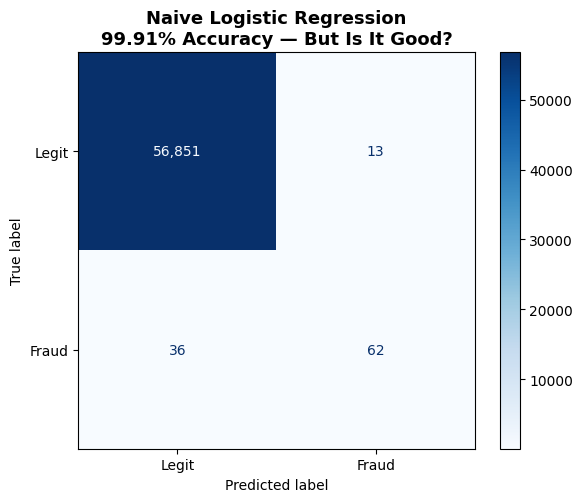

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_naive,
    display_labels=['Legit', 'Fraud'],
    cmap='Blues', ax=ax, values_format=','
)
ax.set_title('Naive Logistic Regression\n99.91% Accuracy — But Is It Good?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()